In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
from Temis.dataloader import German

# Common Auxiliary Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Uncommon Auxiliary Libraries
import jax 
import jax.numpy as jnp

# Machine Learning Models Libraries
from Temis.models import LogisticRegression as FairLR
from Temis.models import MinimaxFairness
from sklearn.linear_model import LogisticRegression as SKLearnLR

# Machine Learning Metrics Libraries
from sklearn.metrics import roc_auc_score, log_loss
from Temis.comparison_utils.cmp_fairness import extract_fairness

# Testing the dataloader definition

In [4]:
german_preprocessed_path = os.path.join('..', 'data', 'preprocessed', 'german.csv')
german = German(german_preprocessed_path)
X_train, y_train = german.get_train_data()
X_test, y_test = german.get_test_data()
print(X_train['ForeignWorker_A202'])

554    0.0
762    0.0
414    0.0
928    0.0
967    0.0
      ... 
71     0.0
280    0.0
478    0.0
784    0.0
747    0.0
Name: ForeignWorker_A202, Length: 750, dtype: float64


# Testing the Rpr logistic regression

In [5]:
s_attribute = 'ForeignWorker_A202'

In [14]:
model_fair = FairLR(epochs=100, penalty='l2', penalty_weight=1.0, fair_penalty='Rpr', fair_penalty_weight=10.0)
model_fair.fit(X_train, y_train, S=X_train['ForeignWorker_A202'], debug=False)
fair_pred_test = model_fair.predict(X_test)
fair_prob_test = model_fair.predict_proba(X_test)

In [9]:
# By default uses 'l2' penalty
model_sk = SKLearnLR(solver='lbfgs', max_iter=1000)
model_sk.fit(X_train, y_train)
sk_pred_test = model_sk.predict(X_test)
sk_prob_test = model_sk.predict(X_test)

In [15]:
print(f'AUC: {roc_auc_score(y_test, fair_prob_test)}')
print(f'AUC: {roc_auc_score(y_test, sk_prob_test)}')

AUC: 0.6939475253428742
AUC: 0.675536672629696


# Testing the MinimaxFairness Approach

In [19]:
mask0_train = X_train[s_attribute] == 0
mask1_train = X_train[s_attribute] == 1

mask0_test = X_test[s_attribute] == 0
mask1_test = X_test[s_attribute] == 1

baseline_model = SKLearnLR(solver='lbfgs', max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_pred_train_class0 = log_loss(y_train[mask0_train], baseline_model.predict_proba(X_train)[mask0_train])
baseline_pred_train_class1 = log_loss(y_train[mask1_train], baseline_model.predict_proba(X_train)[mask1_train])

baseline_pred_test_class0 = log_loss(y_test[mask0_test], baseline_model.predict_proba(X_test)[mask0_test])
baseline_pred_test_class1 = log_loss(y_test[mask1_test], baseline_model.predict_proba(X_test)[mask1_test])

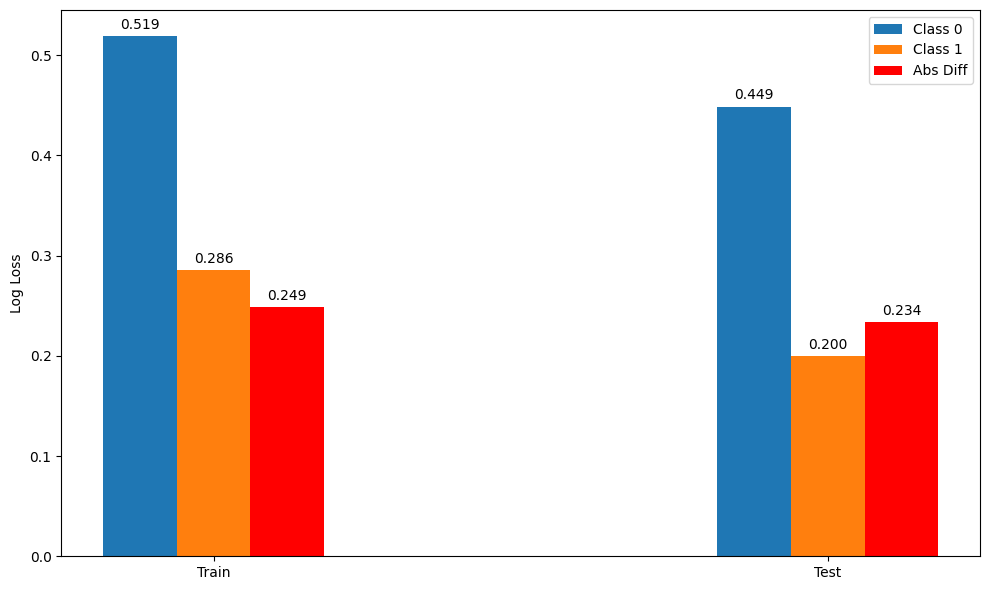

In [28]:
# Fairness log-loss comparison for the standard sklearnLr.

labels = ['Train', 'Test']
loss_class0 = [baseline_pred_test_class0, baseline_pred_train_class0]
loss_class1 = [baseline_pred_test_class1, baseline_pred_train_class1]

diff_train = abs(baseline_pred_train_class0 - baseline_pred_train_class1)
diff_test = abs(baseline_pred_test_class0 - baseline_pred_test_class1)
loss_diff = [diff_train, diff_test]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
bars_class0 = ax.bar(
    x - width/3,
    loss_class0,
    width/3,
    label='Class 0',
    color='#1f77b4'
)

bars_class1 = ax.bar(
    x,
    loss_class1,
    width/3,
    label='Class 1',
    color='#ff7f0e'
)

bars_diff = ax.bar(
    x + width/3,
    loss_diff,
    width/3,
    label='Abs Diff',
    color='#ff0000'
)

ax.set_ylabel('Log Loss')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(bars_class0, padding=3, fmt='%.3f')
ax.bar_label(bars_class1, padding=3, fmt='%.3f')
ax.bar_label(bars_diff, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

In [32]:
model_base = SKLearnLR(solver='lbfgs', max_iter=250)
mm_model = MinimaxFairness(model_base, iter=1000)
mm_model.fit(X_train, y_train, X_train[s_attribute])

In [33]:
mm_pred_train_class0 = log_loss(y_train[mask0_train], mm_model.predict_proba(X_train)[mask0_train])
mm_pred_train_class1 = log_loss(y_train[mask1_train], mm_model.predict_proba(X_train)[mask1_train])

mm_pred_test_class0 = log_loss(y_test[mask0_test], mm_model.predict_proba(X_test)[mask0_test])
mm_pred_test_class1 = log_loss(y_test[mask1_test], mm_model.predict_proba(X_test)[mask1_test])

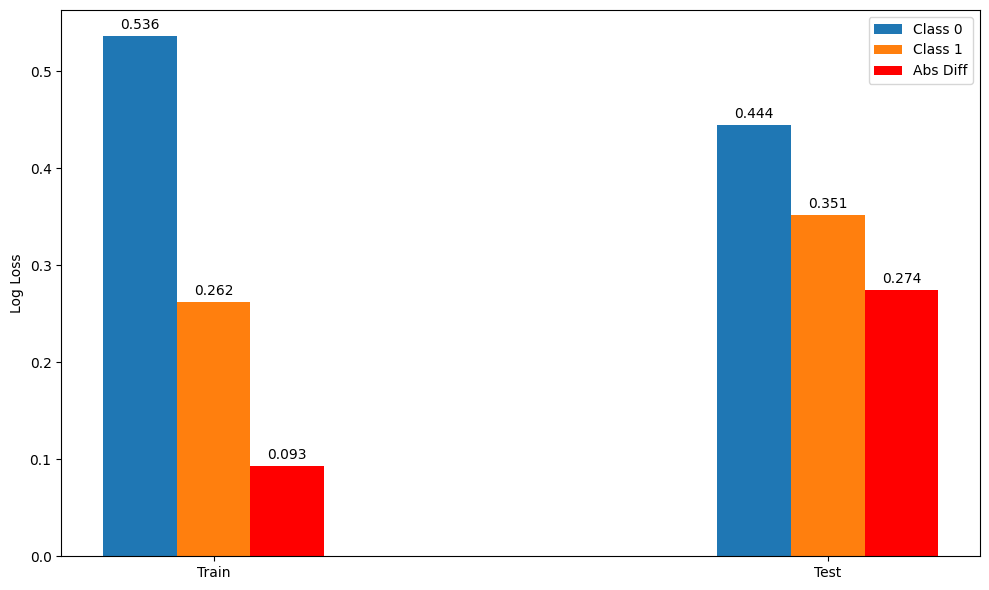

In [34]:
# Fairness log-loss comparison for the standard sklearnLr.

labels = ['Train', 'Test']
loss_class0 = [mm_pred_test_class0, mm_pred_train_class0]
loss_class1 = [mm_pred_test_class1, mm_pred_train_class1]

diff_train = abs(mm_pred_train_class0 - mm_pred_train_class1)
diff_test = abs(mm_pred_test_class0 - mm_pred_test_class1)
loss_diff = [diff_train, diff_test]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
bars_class0 = ax.bar(
    x - width/3,
    loss_class0,
    width/3,
    label='Class 0',
    color='#1f77b4'
)

bars_class1 = ax.bar(
    x,
    loss_class1,
    width/3,
    label='Class 1',
    color='#ff7f0e'
)

bars_diff = ax.bar(
    x + width/3,
    loss_diff,
    width/3,
    label='Abs Diff',
    color='#ff0000'
)

ax.set_ylabel('Log Loss')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(bars_class0, padding=3, fmt='%.3f')
ax.bar_label(bars_class1, padding=3, fmt='%.3f')
ax.bar_label(bars_diff, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

# Experimento: Evolução do MinimaxFairness com variação de iter

In [ ]:
# Variar o parâmetro iter e coletar diff_train e diff_test
iter_values = [10, 50, 100, 250, 500, 750, 1000, 1500, 2000]
diff_train_values = []
diff_test_values = []

for iter_param in iter_values:
    print(f"Treinando modelo com iter={iter_param}...")
    
    model_base = SKLearnLR(solver='lbfgs', max_iter=250)
    mm_model = MinimaxFairness(model_base, iter=iter_param)
    mm_model.fit(X_train, y_train, groups=X_train[s_attribute])
    
    # Calcular predições
    mm_pred_train_class0 = log_loss(y_train[mask0_train], mm_model.predict_proba(X_train)[mask0_train])
    mm_pred_train_class1 = log_loss(y_train[mask1_train], mm_model.predict_proba(X_train)[mask1_train])
    
    mm_pred_test_class0 = log_loss(y_test[mask0_test], mm_model.predict_proba(X_test)[mask0_test])
    mm_pred_test_class1 = log_loss(y_test[mask1_test], mm_model.predict_proba(X_test)[mask1_test])
    
    # Calcular diferenças
    diff_train = abs(mm_pred_train_class0 - mm_pred_train_class1)
    diff_test = abs(mm_pred_test_class0 - mm_pred_test_class1)
    
    diff_train_values.append(diff_train)
    diff_test_values.append(diff_test)
    
    print(f"  Diff Train: {diff_train:.4f}, Diff Test: {diff_test:.4f}")

print("Experimento concluído!")

Treinando modelo com iter=10...
  Diff Train: 0.1337, Diff Test: 0.2620
Treinando modelo com iter=50...
  Diff Train: 0.1374, Diff Test: 0.2773
Treinando modelo com iter=100...
  Diff Train: 0.1338, Diff Test: 0.2801
Treinando modelo com iter=250...
  Diff Train: 0.1167, Diff Test: 0.2788
Treinando modelo com iter=500...
  Diff Train: 0.1029, Diff Test: 0.2760
Treinando modelo com iter=750...
  Diff Train: 0.0964, Diff Test: 0.2746
Treinando modelo com iter=1000...
  Diff Train: 0.0927, Diff Test: 0.2740
Treinando modelo com iter=1500...
  Diff Train: 0.0886, Diff Test: 0.2733
Treinando modelo com iter=2000...
  Diff Train: 0.0865, Diff Test: 0.2729
Experimento concluído!


In [ ]:
# Plotar a evolução das curvas Abs Diff (Train vs Test)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(iter_values, diff_train_values, marker='o', linewidth=2, markersize=8, label='Train', color='#1f77b4')
ax.plot(iter_values, diff_test_values, marker='s', linewidth=2, markersize=8, label='Test', color='#ff7f0e')

ax.set_xlabel('Número de Iterações (iter)', fontsize=12)
ax.set_ylabel('Abs Diff (Log Loss)', fontsize=12)
ax.set_title('Evolução da Fairness com variação do parâmetro iter - MinimaxFairness', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Adicionar valores nos pontos
for i, (iter_val, train_val, test_val) in enumerate(zip(iter_values, diff_train_values, diff_test_values)):
    ax.text(iter_val, train_val + 0.01, f'{train_val:.4f}', ha='center', va='top', fontsize=9)
    ax.text(iter_val, test_val + 0.01, f'{test_val:.4f}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
# Variar o parâmetro iter e coletar diff_train e diff_test
iter_values = [10, 50, 100, 250, 500, 750, 1000, 1500, 2000]
diff_train_values = []
diff_test_values = []

for iter_param in iter_values:
    print(f"Treinando modelo com iter={iter_param}...")
    
    fairLR_model = FairLR(epochs=iter_param, penalty='l2', penalty_weight=1.0, fair_penalty='Rpr', fair_penalty_weight=100.0)
    fairLR_model.fit(X_train, y_train, S=X_train[s_attribute])
    
    # Calcular predições
    fairLR_pred_train_class0 = log_loss(y_train[mask0_train], fairLR_model.predict_proba(X_train)[mask0_train.values])
    fairLR_pred_train_class1 = log_loss(y_train[mask1_train], fairLR_model.predict_proba(X_train)[mask1_train.values])
    
    fairLR_pred_test_class0 = log_loss(y_test[mask0_test], fairLR_model.predict_proba(X_test)[mask0_test.values])
    fairLR_pred_test_class1 = log_loss(y_test[mask1_test], fairLR_model.predict_proba(X_test)[mask1_test.values])
    
    # Calcular diferenças
    diff_train = abs(fairLR_pred_train_class0 - fairLR_pred_train_class1)
    diff_test = abs(fairLR_pred_test_class0 - fairLR_pred_test_class1)
    
    diff_train_values.append(diff_train)
    diff_test_values.append(diff_test)
    
    print(f"  Diff Train: {diff_train:.4f}, Diff Test: {diff_test:.4f}")

print("Experimento concluído!")

Treinando modelo com iter=10...
  Diff Train: 0.2131, Diff Test: 0.0742
Treinando modelo com iter=50...
  Diff Train: 0.1684, Diff Test: 0.0626
Treinando modelo com iter=100...
  Diff Train: 0.1930, Diff Test: 0.0895
Treinando modelo com iter=250...
  Diff Train: 0.1984, Diff Test: 0.0599
Treinando modelo com iter=500...
  Diff Train: 0.2241, Diff Test: 0.0765
Treinando modelo com iter=750...
  Diff Train: 0.2125, Diff Test: 0.0852
Treinando modelo com iter=1000...
  Diff Train: 0.2014, Diff Test: 0.0725
Treinando modelo com iter=1500...
  Diff Train: 0.1899, Diff Test: 0.0780
Treinando modelo com iter=2000...
  Diff Train: 0.1878, Diff Test: 0.0839
Experimento concluído!


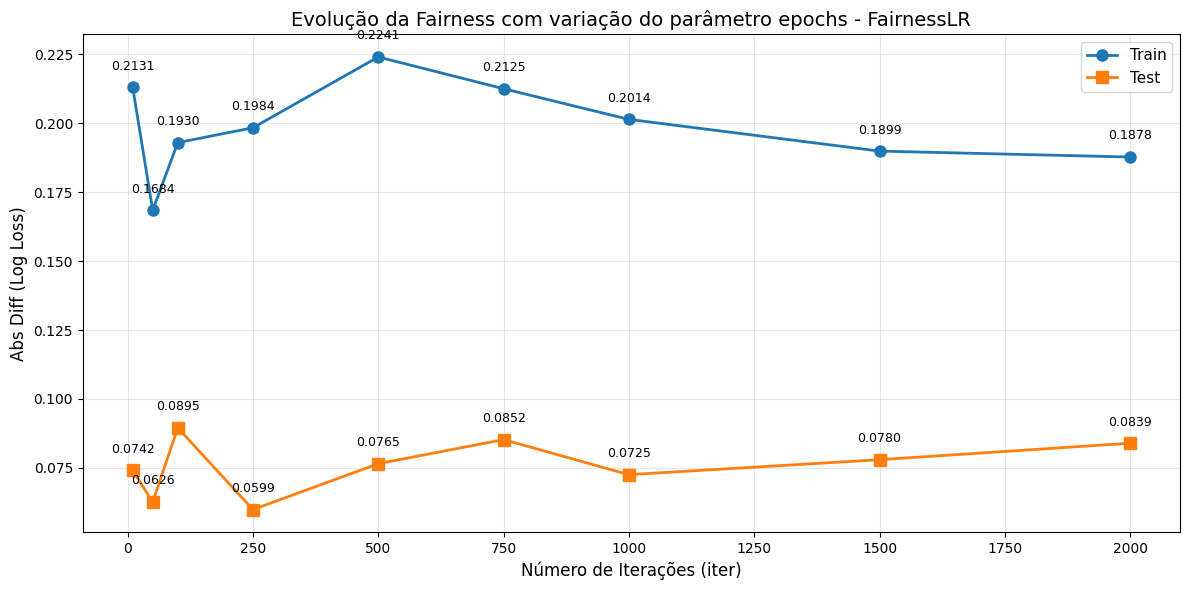

In [35]:
# Plotar a evolução das curvas Abs Diff (Train vs Test)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(iter_values, diff_train_values, marker='o', linewidth=2, markersize=8, label='Train', color='#1f77b4')
ax.plot(iter_values, diff_test_values, marker='s', linewidth=2, markersize=8, label='Test', color='#ff7f0e')

ax.set_xlabel('Número de Iterações (iter)', fontsize=12)
ax.set_ylabel('Abs Diff (Log Loss)', fontsize=12)
ax.set_title('Evolução da Fairness com variação do parâmetro epochs - FairnessLR', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Adicionar valores nos pontos
for i, (iter_val, train_val, test_val) in enumerate(zip(iter_values, diff_train_values, diff_test_values)):
    ax.text(iter_val, train_val + 0.01, f'{train_val:.4f}', ha='center', va='top', fontsize=9)
    ax.text(iter_val, test_val + 0.01, f'{test_val:.4f}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()